In [1]:
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt

I0000 00:00:1782740767.522030    1444 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782740771.237439    1444 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782740776.962027    1444 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


(256, 256, 3)

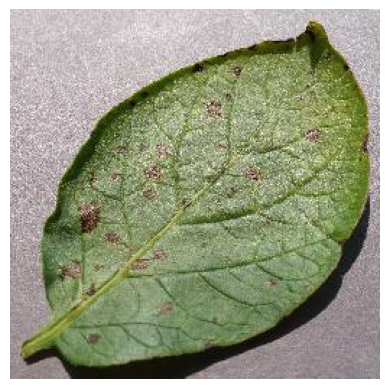

In [2]:
img = mpimg.imread('/home/shahid_mulani/ml_work/plant_disease_detection/data/Potato___Early_blight/0bbb8bce-2020-416b-8bd6-c160c2db9921___RS_Early.B 8386.JPG')
plt.imshow(img)
plt.axis('off')
img.shape

In [3]:
BATCH_SIZE = 32
IMAGE_SIZE = 128  
CHANNELS = 3
EPOCHS = 15
DATA_DIR = "data" 

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 16511 files for training.


I0000 00:00:1782740787.038541    1444 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2244 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

Found 20638 files belonging to 15 classes.
Using 4127 files for validation.


In [6]:
class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"\nSuccessfully loaded {NUM_CLASSES} classes: {class_names}")


Successfully loaded 15 classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [7]:
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

model = models.Sequential([
   
    layers.Input(shape=input_shape),
    
  
    data_augmentation,
    layers.Rescaling(1.0 / 255),  
    
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
  
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
  
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
   
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  
    
 
    layers.Dense(NUM_CLASSES, activation='softmax')
])




In [10]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,815 (4.50 MB)

 Trainable params: 1,180,815 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',        
    patience=4,                
    restore_best_weights=True, 
    verbose=1
)

In [13]:
print("\nStarting model training...")
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)


Starting model training...
Epoch 1/15


W0000 00:00:1782740796.234719    1686 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 8388864 bytes after encountering the first element of size 8388864 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1782740799.380334    1584 cuda_dnn.cc:461] Loaded cuDNN version 92200


516/516 ━━━━━━━━━━━━━━━━━━━━ 33s 44ms/step - accuracy: 0.3593 - loss: 1.9677 - val_accuracy: 0.5915 - val_loss: 1.2204
Epoch 2/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.5788 - loss: 1.2829 - val_accuracy: 0.6976 - val_loss: 0.8793
Epoch 3/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.6636 - loss: 1.0170 - val_accuracy: 0.7727 - val_loss: 0.6402
Epoch 4/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 21s 41ms/step - accuracy: 0.7086 - loss: 0.8696 - val_accuracy: 0.7402 - val_loss: 0.7514
Epoch 5/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7456 - loss: 0.7531 - val_accuracy: 0.8667 - val_loss: 0.3903
Epoch 6/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 23s 44ms/step - accuracy: 0.7815 - loss: 0.6580 - val_accuracy: 0.8166 - val_loss: 0.5367
Epoch 7/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 22s 42ms/step - accuracy: 0.7988 - loss: 0.6032 - val_accuracy: 0.8444 - val_loss: 0.4645
Epoch 8/15
516/516 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.8163 - loss: 0.5439 - val_accurac

In [14]:
model.save('plant_disease_model.keras')

In [15]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

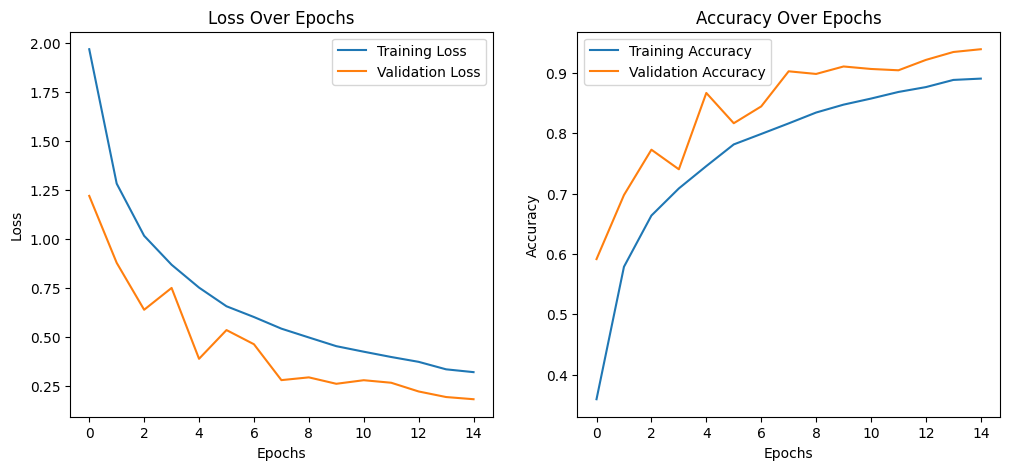

In [17]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(training_loss, label='Training Loss')
plt.plot(validation_loss, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(training_accuracy, label='Training Accuracy')
plt.plot(validation_accuracy, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

In [18]:
import numpy as np

# Initialize empty lists to hold our labels
y_true = []
y_pred = []

print("Evaluating model and generating predictions...")

# Loop through the validation dataset batch by batch
for images, labels in val_ds:
    # 1. Store the true labels
    y_true.extend(labels.numpy())
    
    # 2. Predict the batch
    batch_predictions = model.predict(images, verbose=0)
    
    # 3. Convert probabilities to class indices (e.g., [0.1, 0.8, 0.1] -> Class 1)
    batch_predicted_labels = np.argmax(batch_predictions, axis=1)
    y_pred.extend(batch_predicted_labels)

# Convert to numpy arrays for Scikit-learn
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Extraction complete!")

Evaluating model and generating predictions...
Extraction complete!


In [19]:
from sklearn.metrics import classification_report

# Print the text report
print("\n--- Classification Report ---")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


--- Classification Report ---
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.99      0.91      0.95       200
                     Pepper__bell___healthy       0.97      0.98      0.98       302
                      Potato___Early_blight       0.92      0.97      0.95       189
                       Potato___Late_blight       0.96      0.86      0.91       188
                           Potato___healthy       0.92      0.71      0.80        31
                      Tomato_Bacterial_spot       0.97      0.95      0.96       441
                        Tomato_Early_blight       0.85      0.86      0.86       191
                         Tomato_Late_blight       0.94      0.86      0.90       341
                           Tomato_Leaf_Mold       0.85      0.99      0.92       185
                  Tomato_Septoria_leaf_spot       0.92      0.91      0.92       392
Tomato_Spider_mites_Two_spotted_s